# XGBoost Tuning — Optuna Bayesian Optimization
Tìm siêu tham số tốt nhất cho model XGBoost dự đoán giá iPhone.
- **80 trials** Optuna TPE Sampler
- **5-Fold Cross Validation**
- So sánh Baseline vs Best model

## 1. Import thư viện

In [1]:
import pandas as pd
import numpy as np
import warnings
import pickle
import os
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

warnings.filterwarnings('ignore')
os.makedirs('output', exist_ok=True)
print('Import xong!')

Import xong!


c:\Users\ADMIN\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Đọc & chuẩn bị dữ liệu

In [2]:
CSV_PATH = r'output/Iphone_Database_filtered_train.csv'
df = pd.read_csv(CSV_PATH)

X = df.drop(columns=['Giá', 'Tình trạng pin'])
y = df['Giá']

numeric_features     = ['Dung lượng (GB)']
categorical_features = [c for c in X.columns if c not in numeric_features]

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
    ('num', 'passthrough', numeric_features),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Du lieu: {X_train.shape[0]} train | {X_test.shape[0]} test')
print(f'Features category: {categorical_features}')
print(f'Features so: {numeric_features}')

Du lieu: 856 train | 214 test
Features category: ['Dòng máy', 'Phiên bản', 'Tình trạng', 'Tinh_trang_tong_hop', 'Xuất xứ', 'Pin_bucket', 'Chính sách bảo hành']
Features so: ['Dung lượng (GB)']


## 3. Baseline Model

In [3]:
def make_pipeline(params: dict) -> Pipeline:
    model = XGBRegressor(
        objective='reg:squarederror',
        eval_metric='rmse',
        random_state=42,
        n_jobs=-1,
        **params,
    )
    return Pipeline([('pre', preprocessor), ('model', model)])

BASELINE_PARAMS = dict(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
)

print('Training baseline model...')
baseline_pipe = make_pipeline(BASELINE_PARAMS)
baseline_pipe.fit(X_train, y_train)

base_pred = baseline_pipe.predict(X_test)
base_mae  = mean_absolute_error(y_test, base_pred)
base_rmse = mean_squared_error(y_test, base_pred) ** 0.5
base_r2   = r2_score(y_test, base_pred)

print(f'Baseline -> MAE: {base_mae:,.0f} VND | RMSE: {base_rmse:,.0f} | R2: {base_r2:.4f}')

Training baseline model...
Baseline -> MAE: 1,311,643 VND | RMSE: 2,006,013 | R2: 0.9340


## 4. Optuna Bayesian Optimization (80 trials)

In [4]:
CV = KFold(n_splits=5, shuffle=True, random_state=42)

def objective(trial: optuna.Trial) -> float:
    params = dict(
        n_estimators      = trial.suggest_int('n_estimators', 200, 1000, step=50),
        max_depth         = trial.suggest_int('max_depth', 3, 10),
        learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        subsample         = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree  = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        colsample_bylevel = trial.suggest_float('colsample_bylevel', 0.5, 1.0),
        min_child_weight  = trial.suggest_int('min_child_weight', 1, 10),
        gamma             = trial.suggest_float('gamma', 0.0, 1.0),
        reg_alpha         = trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        reg_lambda        = trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
    )
    pipe   = make_pipeline(params)
    scores = cross_val_score(
        pipe, X_train, y_train,
        cv=CV, scoring='neg_mean_absolute_error', n_jobs=-1
    )
    return -scores.mean()

N_TRIALS = 80  # Tang len 150 neu muon tot hon
print(f'Optuna dang tim tham so ({N_TRIALS} trials)...')

study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10),
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

best_params = study.best_params
print(f'\nBest MAE (CV): {study.best_value:,.0f} VND')
print('\nBest params:')
for k, v in best_params.items():
    print(f'   {k}: {v}')

Optuna dang tim tham so (80 trials)...


Best trial: 79. Best value: 1.35253e+06: 100%|██████████| 80/80 [00:27<00:00,  2.90it/s]


Best MAE (CV): 1,352,534 VND

Best params:
   n_estimators: 800
   max_depth: 3
   learning_rate: 0.06612172349236692
   subsample: 0.9986048283774268
   colsample_bytree: 0.8452311264317203
   colsample_bylevel: 0.5017760667519303
   min_child_weight: 3
   gamma: 0.37930548611035103
   reg_alpha: 0.004420008500627233
   reg_lambda: 0.020896393265256025


## 5. Train lại với tham số tốt nhất

In [5]:
print('Training model voi tham so toi uu...')
best_pipe = make_pipeline(best_params)
best_pipe.fit(X_train, y_train)

best_pred = best_pipe.predict(X_test)
best_mae  = mean_absolute_error(y_test, best_pred)
best_rmse = mean_squared_error(y_test, best_pred) ** 0.5
best_r2   = r2_score(y_test, best_pred)

print('\n' + '='*55)
print(f'{"":20s} {"Baseline":>15s} {"Best (Optuna)":>15s}')
print('='*55)
print(f'{"MAE (VND)":20s} {base_mae:>15,.0f} {best_mae:>15,.0f}')
print(f'{"RMSE (VND)":20s} {base_rmse:>15,.0f} {best_rmse:>15,.0f}')
print(f'{"R2":20s} {base_r2:>15.4f} {best_r2:>15.4f}')
improvement = (base_mae - best_mae) / base_mae * 100
print('='*55)
print(f'Cai thien MAE: {improvement:+.2f}%')

Training model voi tham so toi uu...

                            Baseline   Best (Optuna)
MAE (VND)                  1,311,643       1,333,692
RMSE (VND)                 2,006,013       1,980,084
R2                            0.9340          0.9356
Cai thien MAE: -1.68%


## 6. Biểu đồ kết quả

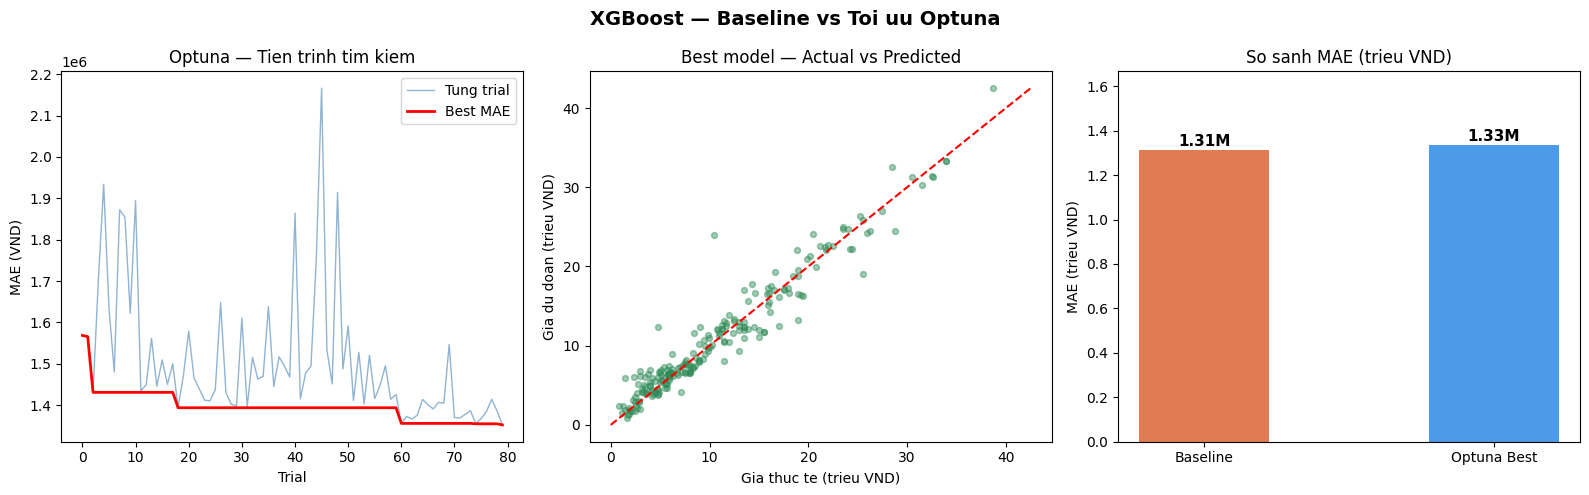

Bieu do luu tai: output/xgboost_tuning_result.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('XGBoost — Baseline vs Toi uu Optuna', fontsize=14, fontweight='bold')

# Optuna optimization history
ax = axes[0]
trial_values = [t.value for t in study.trials if t.value is not None]
ax.plot(trial_values, color='steelblue', linewidth=1, alpha=0.6, label='Tung trial')
running_min = pd.Series(trial_values).cummin()
ax.plot(running_min, color='red', linewidth=2, label='Best MAE')
ax.set_title('Optuna — Tien trinh tim kiem')
ax.set_xlabel('Trial'); ax.set_ylabel('MAE (VND)')
ax.legend()

# Actual vs Predicted
ax = axes[1]
lim = max(y_test.max(), best_pred.max()) / 1e6
ax.scatter(y_test / 1e6, best_pred / 1e6, alpha=0.45, s=18, color='seagreen')
ax.plot([0, lim], [0, lim], 'r--', linewidth=1.5)
ax.set_title('Best model — Actual vs Predicted')
ax.set_xlabel('Gia thuc te (trieu VND)')
ax.set_ylabel('Gia du doan (trieu VND)')

# So sanh MAE
ax = axes[2]
labels = ['Baseline', 'Optuna Best']
values = [base_mae / 1e6, best_mae / 1e6]
bars = ax.bar(labels, values, color=['#e07b54', '#4c9be8'], width=0.45)
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.02,
            f'{v:.2f}M', ha='center', fontsize=11, fontweight='bold')
ax.set_title('So sanh MAE (trieu VND)')
ax.set_ylabel('MAE (trieu VND)')
ax.set_ylim(0, max(values) * 1.25)

plt.tight_layout()
plt.savefig('output/xgboost_tuning_result.png', dpi=150, bbox_inches='tight')
plt.show()
print('Bieu do luu tai: output/xgboost_tuning_result.png')

## 7. Feature Importance

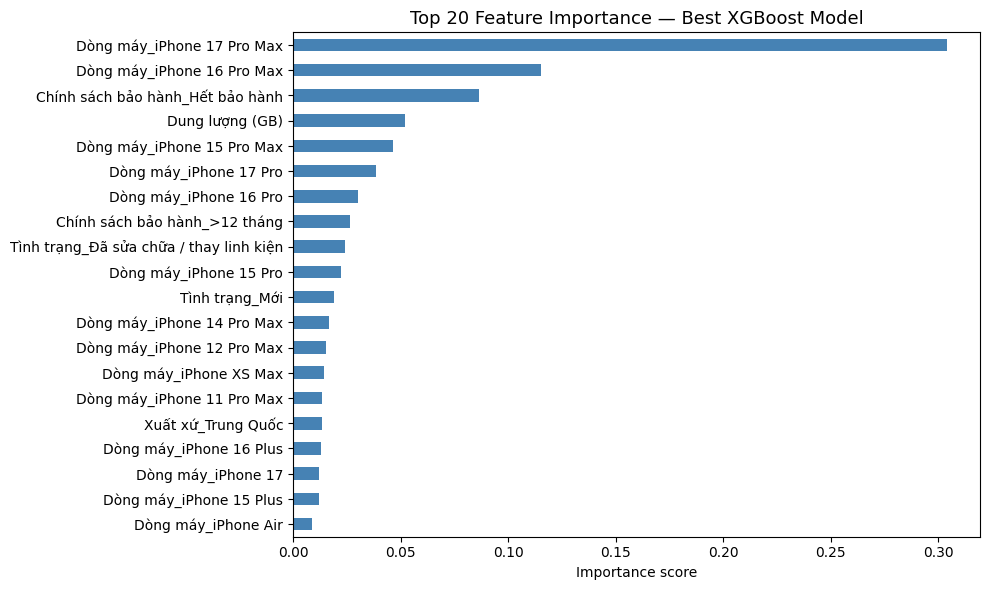

Luu tai: output/feature_importance_best.png


In [7]:
ohe_names = best_pipe.named_steps['pre'] \
    .named_transformers_['cat'] \
    .get_feature_names_out(categorical_features).tolist()
all_names   = ohe_names + numeric_features
importances = best_pipe.named_steps['model'].feature_importances_
feat_imp    = pd.Series(importances, index=all_names).sort_values(ascending=False).head(20)

fig2, ax2 = plt.subplots(figsize=(10, 6))
feat_imp.plot(kind='barh', ax=ax2, color='steelblue')
ax2.invert_yaxis()
ax2.set_title('Top 20 Feature Importance — Best XGBoost Model', fontsize=13)
ax2.set_xlabel('Importance score')
plt.tight_layout()
plt.savefig('output/feature_importance_best.png', dpi=150, bbox_inches='tight')
plt.show()
print('Luu tai: output/feature_importance_best.png')

## 8. Lưu model & in tham số tốt nhất

In [8]:
with open('output/xgboost_best_model.pkl', 'wb') as f:
    pickle.dump(best_pipe, f)
print('Model tot nhat da luu: output/xgboost_best_model.pkl')

print('\nCopy tham so nay vao notebook:')
print('xgb_model = XGBRegressor(')
for k, v in best_params.items():
    if isinstance(v, float):
        print(f'    {k}={v:.6f},')
    else:
        print(f'    {k}={v},')
print("    objective='reg:squarederror',")
print('    random_state=42, n_jobs=-1,')
print(')')

Model tot nhat da luu: output/xgboost_best_model.pkl

Copy tham so nay vao notebook:
xgb_model = XGBRegressor(
    n_estimators=800,
    max_depth=3,
    learning_rate=0.066122,
    subsample=0.998605,
    colsample_bytree=0.845231,
    colsample_bylevel=0.501776,
    min_child_weight=3,
    gamma=0.379305,
    reg_alpha=0.004420,
    reg_lambda=0.020896,
    objective='reg:squarederror',
    random_state=42, n_jobs=-1,
)
